# Comparative Analysis of Machaine Learning Model for Diabetes Prediction Classification
**Objective** : Evaluate and compare the performance of six different classification algorithms

**Models Evaluated:**
* Logistic Regression
* Support Vector Machine (SVM)
* K-Nearest Neighbors (KNN)
* Random Forest
* Gradient Boosting Machine
* XGBoost

## 1. Import Libraries And Setup

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Settings
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All Libraries Loaded Succesfully")

All Libraries Loaded Succesfully


## 2. Load and Explore Data

In [2]:
# Load Dataset
df = pd.read_csv("diabetes.csv")

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset Shape: (768, 8)

First few rows:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,50,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,52,1
3,150,66,23,94,28.1,0.167,21,0
4,150,40,35,168,43.1,2.288,33,1


In [3]:
# Dataset information
print("Dataset Info:")
print(f"Total samples: {len(df)}")
print(f"Total features: {df.shape[1] - 1}") # excluding outcome
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nClass Distribution:")
print(df['Outcome'].value_counts())
print(f"\nClass Balance:")
print(df['Outcome'].value_counts(normalize=True).round(3))

Dataset Info:
Total samples: 768
Total features: 7

Missing values: 0

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


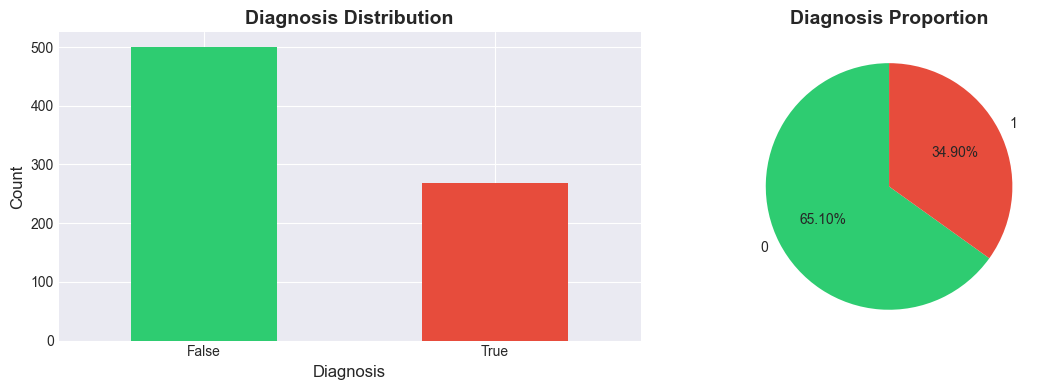

In [4]:
# Visualize Class distribution
fig, axes =  plt.subplots(1, 2, figsize=(12,4))

# Count plot
df['Outcome'].value_counts().plot(kind='bar',ax=axes[0],color=['#2ecc71','#e74c3c'])
axes[0].set_title('Diagnosis Distribution',fontsize=14,fontweight='bold')
axes[0].set_xlabel('Diagnosis',fontsize=12)
axes[0].set_ylabel('Count',fontsize=12)
axes[0].set_xticklabels(['False','True'],rotation=0)

# Pie Chart
df['Outcome'].value_counts().plot(kind='pie',ax=axes[1],autopct='%1.2f%%',
                           colors=['#2ecc71','#e74c3c'],startangle=90)
axes[1].set_title('Diagnosis Proportion',fontsize=14,fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [5]:
# Prepare feature and target
X= df.drop('Outcome',axis=1)
y=df['Outcome']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature names ({len(X.columns)}):")
print(X.columns.tolist())

Feature matrix shape: (768, 7)
Target vector shape: (768,)

Feature names (7):
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [6]:
# Feature Statistics
print("Feature Statistics:")
X.describe().round(2)

Feature Statistics:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,121.12,69.08,20.54,79.80,31.99,0.47,33.24
std,31.81,19.37,15.95,115.24,7.88,0.33,11.76
min,0.00,0.00,0.00,0.00,0.00,0.08,21.00
25%,99.00,62.00,0.00,0.00,27.30,0.24,24.00
50%,117.00,72.00,23.00,30.50,32.00,0.37,29.00
75%,142.00,80.00,32.00,127.25,36.60,0.63,41.00
max,199.00,122.00,99.00,846.00,67.10,2.42,81.00


In [7]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42, stratify=y
)

print(f"Training Set Size :{len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrainin set class distribution")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training Set Size :614 (79.9%)
Test set size: 154 (20.1%)

Trainin set class distribution
Outcome
0    400
1    214
Name: count, dtype: int64

Test set class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [8]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling completed")
print(f"\nScaled feature statistics (first 5 feature):")
print(f"Mean: {X_train_scaled[:,:5].mean(axis=0).round(3)}")
print(f"Std: {X_train_scaled[:,:5].std(axis=0).round(3)}")

Feature Scaling completed

Scaled feature statistics (first 5 feature):
Mean: [ 0.  0. -0. -0.  0.]
Std: [1. 1. 1. 1. 1.]


In [21]:
# Handling Class imbalance
smote = SMOTE(sampling_strategy=0.6, random_state=42)  # 60% ratio instead of 80%
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


print(f"Original training shape: {X_train_scaled.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}")
print(f"With 0.6 ratio: {pd.Series(y_train_resampled).value_counts()}")

Original training shape: (614, 7)
Resampled training shape: (640, 7)
With 0.6 ratio: Outcome
0    400
1    240
Name: count, dtype: int64


## 4. Model Trainin and Evaluation

In [27]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', C=0.1, max_iter=1000, random_state=42
    ),
    'SVM': SVC(
        class_weight={0:1, 1:2.5}, kernel='rbf', probability=True, C=10, random_state=42
    ),
    'KNN': KNeighborsClassifier(n_neighbors=7),  # Increase neighbors
    'Random Forest': RandomForestClassifier(
        class_weight={0:1, 1:2},
        n_estimators=100,  # Reduce from 300
        max_depth=5,       # Reduce from 10
        min_samples_split=20,  # Increase (prevents overfitting)
        min_samples_leaf=10,   # Increase (prevents overfitting)
        max_features='sqrt',   # Reduce feature sampling
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.01,      # Slower learning
    n_estimators=300,        # More trees
    subsample=0.8,
    max_features='sqrt',
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=1.5,  # Reduce from 1.87
        max_depth=3,           # Reduce from 6
        learning_rate=0.01,    # Reduce from 0.05
        n_estimators=100,      # Reduce from 300
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=5,    # Increase (prevents overfitting)
        reg_alpha=0.1,         # Add L1 regularization
        reg_lambda=1.0,        # Add L2 regularization
        eval_metric='logloss',
        random_state=42
    )
}
print(f"Initialized {len(models)} models for comparison")

<IPython.core.display.Javascript object>

Initialized 6 models for comparison


In [34]:
# Train models and collect results
results=[]
trained_models={}
predictions={}
probabilities={}

print("Training models....\n")

for name,model in models.items():
    print(f"Training {name}...",end=' ')

    # Use Scaled data for models that benefit from it
    if name in ['Logistic Regression','SVM','KNN']:
        model.fit(X_train_resampled,y_train_resampled)
        y_pred=model.predict(X_test_scaled)
        y_prob=model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train,y_train)
        y_pred= model.predict(X_test)
        y_prob= model.predict_proba(X_test)[:, 1]
        
    # Store model and prediction
    trained_models[name] = model
    predictions[name] = y_pred
    probabilities[name] = y_prob

    # Calculate metrics
    acc= accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,y_pred)
    rec = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    # Cross-validation score
    if name in ['Logistic Regression','SVM','KNN']:
        cv_scores = cross_val_score(model, X_train_resampled,y_train_resampled,cv=5)
    else:
        cv_scores = cross_val_score(model,X_train,y_train,cv=5)

    results.append({
        'Model': name,
        'Accuracy': round(acc,4),
        'Precision': round(prec,4),
        'Recall': round(rec,4),
        'F1-Score': round(f1,4),
        'CV Score': round(cv_scores.mean(),4)
    })

    print(f" (Accuracy: {acc:.4f})")
print("\nAll Models trained succesfully!")

Training models....

Training Logistic Regression...  (Accuracy: 0.7532)
Training SVM...  (Accuracy: 0.7792)
Training KNN...  (Accuracy: 0.7338)
Training Random Forest...  (Accuracy: 0.7727)
Training Gradient Boosting...  (Accuracy: 0.7468)
Training XGBoost...  (Accuracy: 0.7532)

All Models trained succesfully!


## 5. Results Comparison

In [35]:
# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy',ascending=False).reset_index(drop=True)

print("="*80)
print('MODEL PERFORMANCE COMPARISON')
print('='*80)
print(results_df.to_string(index=False))
print('='*80)

# Highlight best model
best_model = results_df.iloc[0]['Model']
best_acc = results_df.iloc[0]['Accuracy']
print(f"\n Best Model: {best_model} (Accuracy: {best_acc})")

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  CV Score
                SVM    0.7792     0.6562  0.7778    0.7119    0.7219
      Random Forest    0.7727     0.6462  0.7778    0.7059    0.7509
Logistic Regression    0.7532     0.6250  0.7407    0.6780    0.7484
            XGBoost    0.7532     0.6667  0.5926    0.6275    0.7753
  Gradient Boosting    0.7468     0.6744  0.5370    0.5979    0.7704
                KNN    0.7338     0.6140  0.6481    0.6306    0.7391

 Best Model: SVM (Accuracy: 0.7792)


## 6. Extreme Push for Our Best Model

In [45]:
# Train your best model (SVM or Random Forest)
best_model = SVC(
    class_weight={0:1, 1:3.5},  # Even more aggressive weighting
    kernel='rbf',
    probability=True,
    C=20,  # Higher C = less regularization
    gamma='scale',
    random_state=42
)

# Apply SMOTE with 0.6 ratio
smote = SMOTE(sampling_strategy=0.6, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Scale and train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

best_model.fit(X_train_scaled, y_train_resampled)

# Get probabilities
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Try VERY aggressive thresholds
for threshold in [0.25, 0.30, 0.35, 0.40]:
    y_pred = (y_proba >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nThreshold: {threshold}")
    print(f"Recall: {recall:.4f}, Precision: {precision:.4f}, F1: {f1:.4f}, Acc: {accuracy:.4f}")


Threshold: 0.25
Recall: 0.8889, Precision: 0.5000, F1: 0.6400, Acc: 0.6494

Threshold: 0.3
Recall: 0.8704, Precision: 0.5595, F1: 0.6812, Acc: 0.7143

Threshold: 0.35
Recall: 0.8148, Precision: 0.5789, F1: 0.6769, Acc: 0.7273

Threshold: 0.4
Recall: 0.7037, Precision: 0.6032, F1: 0.6496, Acc: 0.7338


## 6. Visualization of Results

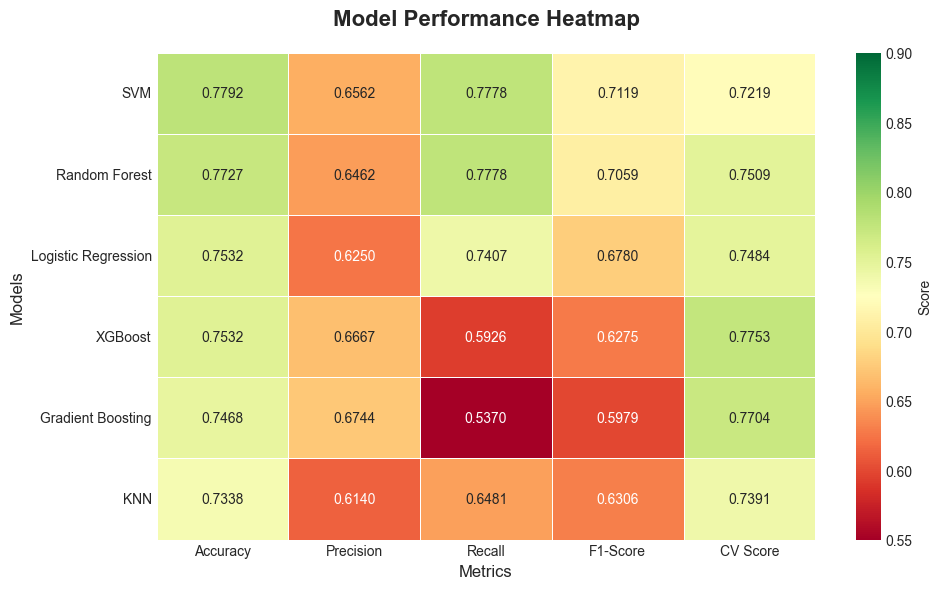

In [43]:
# Overall performance heatmap
plt.figure(figsize=(10, 6))

heatmap_data = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Score']]
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'Score'},
            linewidths=0.5, vmin=0.55, vmax=0.90)

plt.title('Model Performance Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Models', fontsize=12)
plt.tight_layout()
plt.show()